# Best schools in SATs
### Given the data set of the 2012 SAT results, we'll find which schools are performing better in SATs, so that the fundings can be allocated. We will use a dataset containing 478 schools with features : 
* DBN                                    
* SCHOOL NAME
* Num of SAT Test Takers 
* SAT Critical Reading Avg. Score 
* SAT Math Avg. Score
* SAT Writing Avg. Score

## The funding should be alllocated according to the best overall grade and presumambly independently of the school name and the number of students


In [ ]:
import matplotlib.pyplot as plt
import random

import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, MDS, LocallyLinearEmbedding, TSNE 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('2012_SAT_Results.csv')

In [5]:
df.shape

(478, 6)

# Data cleaning & visualization

In [7]:
print(df.head())

      DBN                                    SCHOOL NAME  \
0  01M292  HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES   
1  01M448            UNIVERSITY NEIGHBORHOOD HIGH SCHOOL   
2  01M450                     EAST SIDE COMMUNITY SCHOOL   
3  01M458                      FORSYTH SATELLITE ACADEMY   
4  01M509                        MARTA VALLE HIGH SCHOOL   

  Num of SAT Test Takers SAT Critical Reading Avg. Score SAT Math Avg. Score  \
0                     29                             355                 404   
1                     91                             383                 423   
2                     70                             377                 402   
3                      7                             414                 401   
4                     44                             390                 433   

  SAT Writing Avg. Score  
0                    363  
1                    366  
2                    370  
3                    359  
4                    38

In [8]:
print(df.tail())

        DBN                                 SCHOOL NAME  \
473  75X012            P.S. X012 LEWIS AND CLARK SCHOOL   
474  75X754     J. M. RAPPORT SCHOOL CAREER DEVELOPMENT   
475  79M645  SCHOOL FOR COOPERATIVE TECHNICAL EDUCATION   
476  79Q950                         GED PLUS s CITYWIDE   
477  79X490                             PHOENIX ACADEMY   

    Num of SAT Test Takers SAT Critical Reading Avg. Score  \
473                      s                               s   
474                      s                               s   
475                      s                               s   
476                      8                             496   
477                      9                             367   

    SAT Math Avg. Score SAT Writing Avg. Score  
473                   s                      s  
474                   s                      s  
475                   s                      s  
476                 400                    426  
477                 370    

In [9]:
df.isnull().sum()

DBN                                0
SCHOOL NAME                        0
Num of SAT Test Takers             0
SAT Critical Reading Avg. Score    0
SAT Math Avg. Score                0
SAT Writing Avg. Score             0
dtype: int64

In [10]:
df.describe()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score
count,478,478,478,478,478,478
unique,478,478,175,164,173,163
top,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,s,s,s,s
freq,1,1,57,57,57,57


In [12]:
df['SAT Critical Reading Avg. Score'].min()

'279'

In [52]:
#### Data cleaning: replacing the s values by the average 
# Columns to clean
score_cols = [
    'SAT Critical Reading Avg. Score',
    'SAT Math Avg. Score',
    'SAT Writing Avg. Score'
]

# Replace 's' with NaN
df[score_cols] = df[score_cols].replace('s', pd.NA)

# Convert to numeric
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors='coerce')

# Fill NaNs with column means
df[score_cols] = df[score_cols].fillna(df[score_cols].mean())

df['Num of SAT Test Takers'] = df['Num of SAT Test Takers'].fillna(df['Num of SAT Test Takers'].mean())


In [14]:
print(df.head())

      DBN                                    SCHOOL NAME  \
0  01M292  HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES   
1  01M448            UNIVERSITY NEIGHBORHOOD HIGH SCHOOL   
2  01M450                     EAST SIDE COMMUNITY SCHOOL   
3  01M458                      FORSYTH SATELLITE ACADEMY   
4  01M509                        MARTA VALLE HIGH SCHOOL   

  Num of SAT Test Takers  SAT Critical Reading Avg. Score  \
0                     29                            355.0   
1                     91                            383.0   
2                     70                            377.0   
3                      7                            414.0   
4                     44                            390.0   

   SAT Math Avg. Score  SAT Writing Avg. Score  
0                404.0                   363.0  
1                423.0                   366.0  
2                402.0                   370.0  
3                401.0                   359.0  
4                433.0     

In [15]:
df.describe()

,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score
count,478.000000,478.000000,478.000000
mean,400.850356,413.368171,393.985748
std,53.300964,60.696930,55.020330
min,279.000000,312.000000,286.000000
25%,370.000000,375.000000,363.000000
50%,397.500000,402.500000,387.000000
75%,411.750000,426.750000,403.000000
max,679.000000,735.000000,682.000000


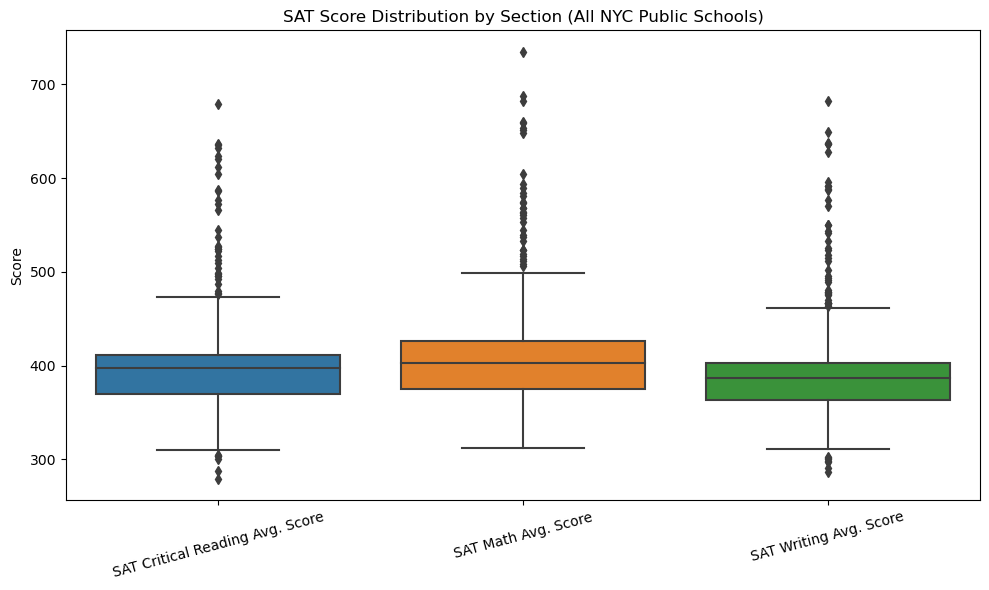

In [17]:
##Visualization of distribution across all schools
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['SAT Critical Reading Avg. Score', 'SAT Math Avg. Score', 'SAT Writing Avg. Score']])
plt.title('SAT Score Distribution by Section (All NYC Public Schools)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# Visualization of highest overall performance

# Adding a total SAT score column
df['Total SAT Score'] = (
    df['SAT Critical Reading Avg. Score'] +
    df['SAT Math Avg. Score'] +
    df['SAT Writing Avg. Score']
)

# Sorting the top 10
top_schools = df.sort_values('Total SAT Score', ascending=False).head(10)

print(top_schools)

        DBN                                        SCHOOL NAME  \
48   02M475                             STUYVESANT HIGH SCHOOL   
198  10X445                       BRONX HIGH SCHOOL OF SCIENCE   
459  31R605                STATEN ISLAND TECHNICAL HIGH SCHOOL   
206  10X696  HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE   
396  25Q525                        TOWNSEND HARRIS HIGH SCHOOL   
427  28Q687  QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...   
8    01M696                     BARD HIGH SCHOOL EARLY COLLEGE   
107  05M692  HIGH SCHOOL FOR MATHEMATICS, SCIENCE AND ENGIN...   
249  13K430                     BROOKLYN TECHNICAL HIGH SCHOOL   
33   02M416                      ELEANOR ROOSEVELT HIGH SCHOOL   

    Num of SAT Test Takers  SAT Critical Reading Avg. Score  \
48                     832                            679.0   
198                    731                            632.0   
459                    227                            635.0   
206                  

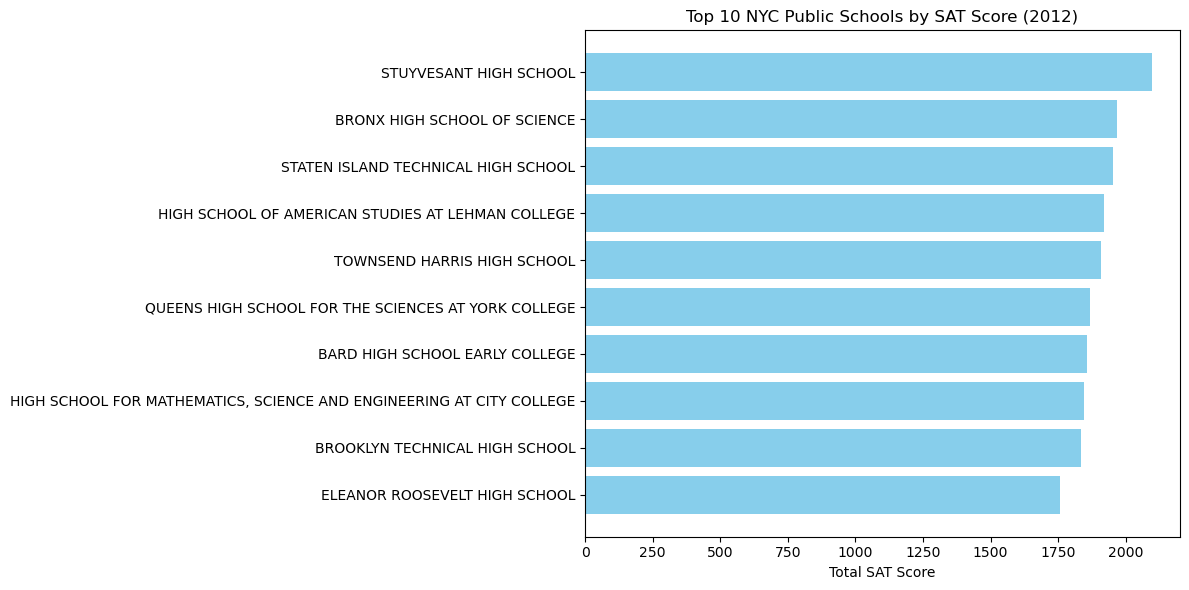

In [22]:
# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_schools['SCHOOL NAME'], top_schools['Total SAT Score'], color='skyblue')
plt.xlabel('Total SAT Score')
plt.title('Top 10 NYC Public Schools by SAT Score (2012)')
plt.gca().invert_yaxis()  # highest score on top
plt.tight_layout()
plt.show()

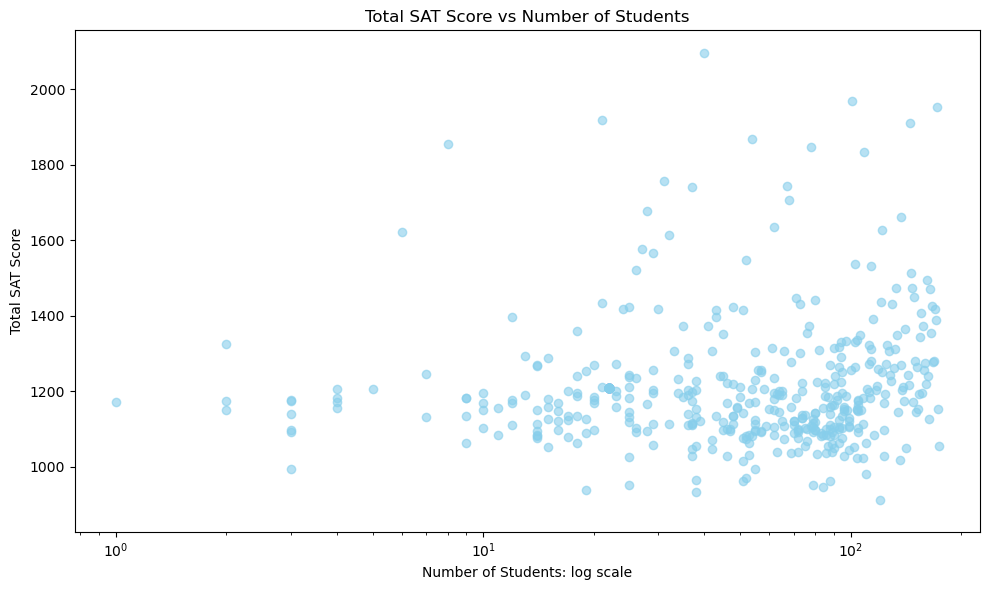

In [30]:
# Visualization of total SAT score vs number of students
plt.figure(figsize=(10, 6))

plt.scatter(df['Num of SAT Test Takers'], df['Total SAT Score'], alpha=0.6, color='skyblue')

plt.xscale('log')
# Add labels and title
plt.xlabel('Number of Students: log scale')
plt.ylabel('Total SAT Score')
plt.title('Total SAT Score vs Number of Students')

plt.tight_layout()
plt.show()

# Analysis


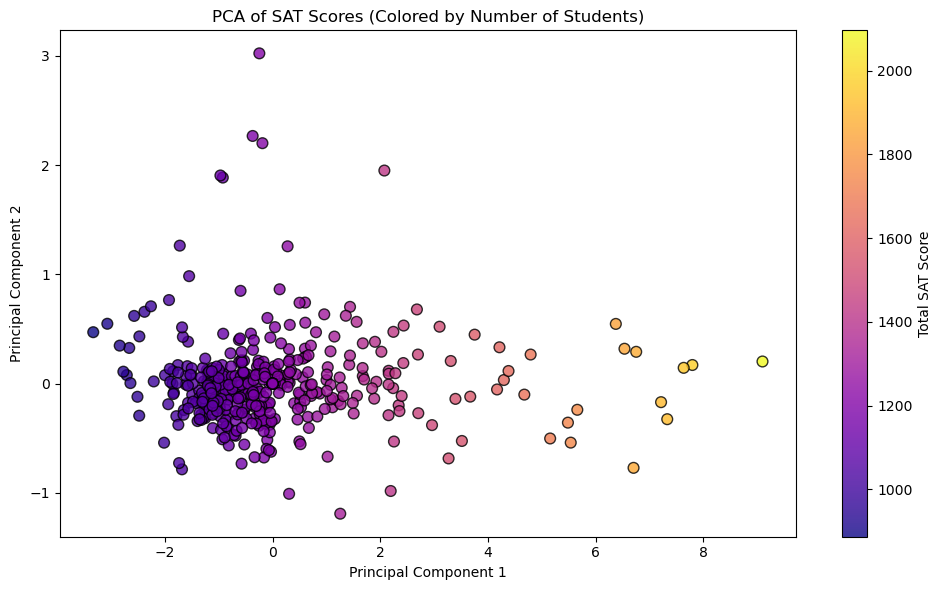

In [40]:
# First we'll use PCA 
X = df[['SAT Critical Reading Avg. Score', 'SAT Math Avg. Score', 'SAT Writing Avg. Score']]

# Standardizing the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA 
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Plot the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['PCA1'], df['PCA2'],
    c=df['Total SAT Score'],
    cmap='plasma',
    s=60,
    alpha=0.8,
    edgecolors='k'
)
plt.colorbar(label='Total SAT Score')
plt.title('PCA of SAT Scores (Colored by Number of Students)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()



#Therefore it seems along Principal component 1 the score increaces and that's a good measure of what is needed for a good score.

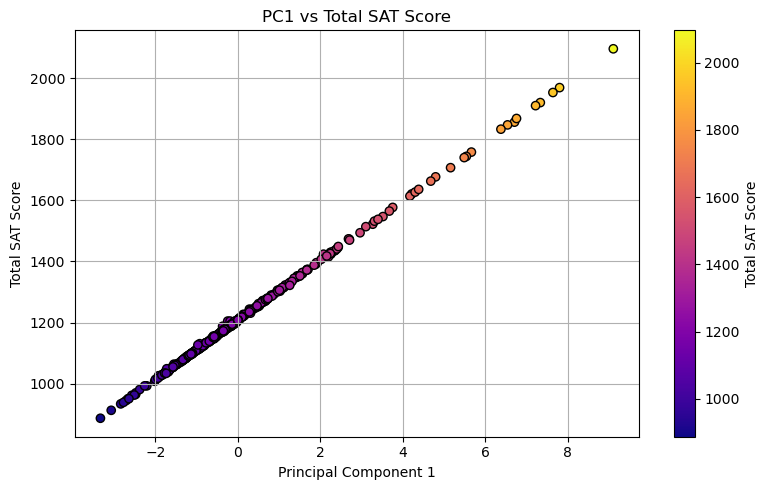

In [74]:
plt.figure(figsize=(8, 5))
plt.scatter(df['PCA1'], df['Total SAT Score'], c=df['Total SAT Score'], cmap='plasma', edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Total SAT Score')
plt.title('PC1 vs Total SAT Score')
plt.grid(True)
plt.colorbar(label='Total SAT Score')
plt.tight_layout()
plt.show()

In [41]:
# Get component loadings
component_1 = pca.components_[0]
features = ['SAT Critical Reading Avg. Score', 'SAT Math Avg. Score', 'SAT Writing Avg. Score']

# Zip feature names with PC1 weights
for feature, weight in zip(features, component_1):
    print(f"{feature}: {weight:.3f}")


SAT Critical Reading Avg. Score: 0.582
SAT Math Avg. Score: 0.564
SAT Writing Avg. Score: 0.585


In [78]:
top_10_pca1 = df.sort_values(by='PCA1', ascending=False).head(10)
print(top_10_pca1['SCHOOL NAME'])


48                                STUYVESANT HIGH SCHOOL
198                         BRONX HIGH SCHOOL OF SCIENCE
459                  STATEN ISLAND TECHNICAL HIGH SCHOOL
206    HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE
396                          TOWNSEND HARRIS HIGH SCHOOL
427    QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...
8                         BARD HIGH SCHOOL EARLY COLLEGE
107    HIGH SCHOOL FOR MATHEMATICS, SCIENCE AND ENGIN...
249                       BROOKLYN TECHNICAL HIGH SCHOOL
33                         ELEANOR ROOSEVELT HIGH SCHOOL
Name: SCHOOL NAME, dtype: object


In [ ]:
# Therefore it's also like  principal component 1 is also proportional to total SAT score

In [44]:
# t-sne

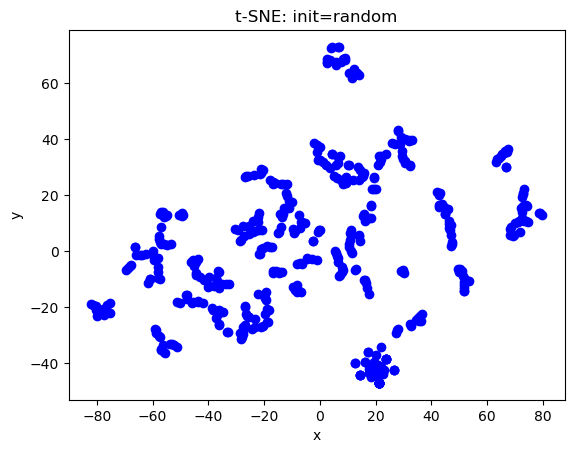

In [59]:
# Now we use SNE: preserves local structure
cols = ['x', 'y']
t_sne = TSNE(
    n_components=2, #Dimension of the embedded space
    # I had to play with perplexity quite a bit: WHAT HAPPENS IF YOU INCREASE/DECREASE IT?
    perplexity=5, # Related to the relationships of the number of nearest neighbors
    metric='euclidean', 
    # Can be random or pca. Try both!
    init='random', 
    verbose=0, 
    random_state=0, 
    # You can also put below 'exact', but you will have to approx double the perplexity factor
    method='barnes_hut',
    n_jobs=-1
)

features = ['SAT Critical Reading Avg. Score', 'SAT Math Avg. Score', 'SAT Writing Avg. Score']
features = features + ['Num of SAT Test Takers']
X = df[features]

t_sne_result = t_sne.fit_transform(X)
t_sne_result = pd.DataFrame(t_sne_result)
t_sne_result.columns = cols
plt.scatter(t_sne_result['x'], t_sne_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('t-SNE: init=random')
plt.show()
print('')

# Result : Therefore we see some clear more or less clusters from t-sne!

# Clustering : DBSCAN

In [60]:
dbscan = DBSCAN(
    eps=10, # Maximum distance between two samples for one to be considered as in the neighborhood of the other.
    min_samples=5, # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    
)
dbscan_clusters = dbscan.fit_predict(t_sne_result)

In [61]:
print(dbscan_clusters)

[ 0  0  0  0  0 -1  1  0  1  0  0  0  0  0  0  2  0  0  0  0  0  0  3  3
 -1  3  4  0  1  1  1  1  0  1  1  0  5  0  3  0  3  3  0  0  0  0  4  3
  5  4  0  0  4  3  0  2  0  0  0  0  0  0  1  0 -1  0  0  5  0  0  4  4
  4  0  0  0  0  3  3  0  0  3  4  1  5  0  0  0  0  3  0  0  5  0  0  0
  0  0  0  0  3  0  0  0  4  0  0  1  0  0  0  3  0  0  0  4  0  4  0  0
  0  6  3  3  0  0  0  0  0  0  0  0  0  0  0  4  3  0  0  0  2  0  0  3
  3  0  5  0  3  0  3  0  0  3  0  0  0  0  0  0  0  0  0  0  2  0  0  3
  0  6  6  0  0  0  0  0  0  3  0  0  0  0  0  0  6  0  3  6  3  0  0  0
  0  0  0  0  5  0  5  4  0  3  2  0  0  0  1  0  0  0  0  0  0  0  0  4
  3  0  4  3  2  0  0  0  0  0  0  0  0  0  0  0  0  6  3  0  3  3  0  6
  2  0  0  0  0  0  0  0  0  5  6  0  0  0  3  0  0  0  0  3  4  0  4  3
  0  1  0  4  3  3  0  0  3  0  4  0  0  3  0  0  0  0  0  0  0  0  3  0
  3  3  0  0  4  0  0  3  0  0  3  0  6  0  0  0  2  0  0  0  0  0  0  0
  4  4  0  3  6  0  0  0  0  0  0  0  0  0  0  0  0

In [64]:
t_sne_result['DBSCAN Cluster'] = dbscan_clusters

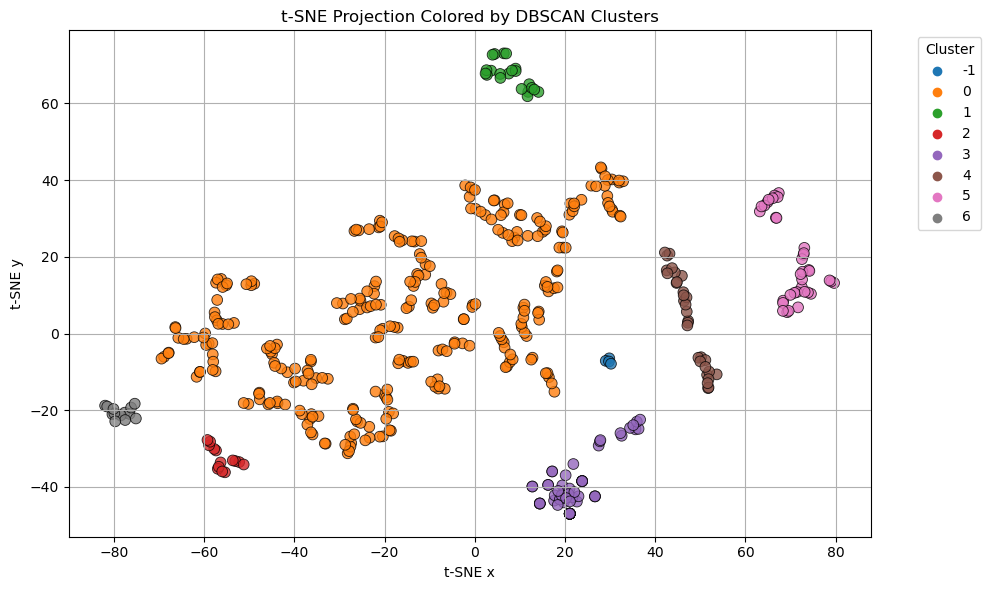

In [65]:
plt.figure(figsize=(10, 6))
# Plot each cluster separately
palette = sns.color_palette("tab10", n_colors=len(t_sne_result['DBSCAN Cluster'].unique()))
sns.scatterplot(
    data=t_sne_result,
    x='x', y='y',
    hue='DBSCAN Cluster',
    palette=palette,
    s=60,
    edgecolor='k',
    alpha=0.8
)

# Plot details
plt.title('t-SNE Projection Colored by DBSCAN Clusters')
plt.xlabel('t-SNE x')
plt.ylabel('t-SNE y')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [67]:
## Seems like a good clustering

In [68]:
## Finding the best cluster

df['DBSCAN Cluster'] = dbscan_clusters
cluster_perf = df.groupby('DBSCAN Cluster')['Total SAT Score'].mean().sort_values(ascending=False)
print(cluster_perf)


DBSCAN Cluster
 1    1700.714286
 5    1374.694444
 4    1227.290323
 3    1209.994760
-1    1181.250000
 0    1169.161512
 2    1049.071429
 6     950.307692
Name: Total SAT Score, dtype: float64


# Best cluster of schools

In [70]:
df[df['DBSCAN Cluster'] == 1][['DBN', 'SCHOOL NAME', 'Total SAT Score']]

,DBN,SCHOOL NAME,Total SAT Score
6,01M539,"NEW EXPLORATIONS INTO SCIENCE, TECHNOLOGY AND ...",1621.0
8,01M696,BARD HIGH SCHOOL EARLY COLLEGE,1856.0
28,02M408,PROFESSIONAL PERFORMING ARTS HIGH SCHOOL,1522.0
29,02M411,BARUCH COLLEGE CAMPUS HIGH SCHOOL,1577.0
30,02M412,N.Y.C. LAB SCHOOL FOR COLLABORATIVE STUDIES,1677.0
31,02M413,SCHOOL OF THE FUTURE HIGH SCHOOL,1565.0
33,02M416,ELEANOR ROOSEVELT HIGH SCHOOL,1758.0
34,02M418,MILLENNIUM HIGH SCHOOL,1614.0
62,02M565,URBAN ACADEMY LABORATORY HIGH SCHOOL,1547.0
83,03M479,BEACON HIGH SCHOOL,1744.0


In [79]:
df[df['DBSCAN Cluster'] == 1][['SCHOOL NAME']]

,SCHOOL NAME
6,"NEW EXPLORATIONS INTO SCIENCE, TECHNOLOGY AND ..."
8,BARD HIGH SCHOOL EARLY COLLEGE
28,PROFESSIONAL PERFORMING ARTS HIGH SCHOOL
29,BARUCH COLLEGE CAMPUS HIGH SCHOOL
30,N.Y.C. LAB SCHOOL FOR COLLABORATIVE STUDIES
31,SCHOOL OF THE FUTURE HIGH SCHOOL
33,ELEANOR ROOSEVELT HIGH SCHOOL
34,MILLENNIUM HIGH SCHOOL
62,URBAN ACADEMY LABORATORY HIGH SCHOOL
83,BEACON HIGH SCHOOL


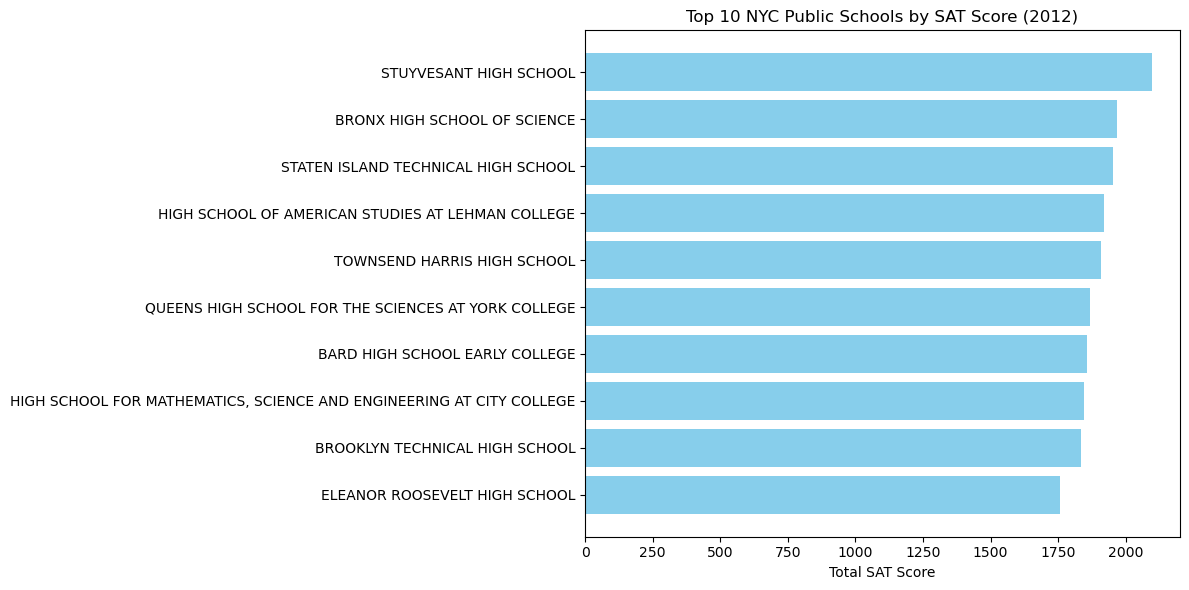

In [80]:
# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_schools['SCHOOL NAME'], top_schools['Total SAT Score'], color='skyblue')
plt.xlabel('Total SAT Score')
plt.title('Top 10 NYC Public Schools by SAT Score (2012)')
plt.gca().invert_yaxis()  # highest score on top
plt.tight_layout()
plt.show()

In [81]:
print(top_10_pca1['SCHOOL NAME'])

48                                STUYVESANT HIGH SCHOOL
198                         BRONX HIGH SCHOOL OF SCIENCE
459                  STATEN ISLAND TECHNICAL HIGH SCHOOL
206    HIGH SCHOOL OF AMERICAN STUDIES AT LEHMAN COLLEGE
396                          TOWNSEND HARRIS HIGH SCHOOL
427    QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...
8                         BARD HIGH SCHOOL EARLY COLLEGE
107    HIGH SCHOOL FOR MATHEMATICS, SCIENCE AND ENGIN...
249                       BROOKLYN TECHNICAL HIGH SCHOOL
33                         ELEANOR ROOSEVELT HIGH SCHOOL
Name: SCHOOL NAME, dtype: object


In [ ]:
## I would say therefore PCA seems to perform quite better and we have our top schools for funding!